### 학습목표
- 네이버 블로그 데이터 수집하기
- 네이버 카페 데이터를 수집했던 경험을 통하여 동일한 프로세스로 블로그 글 수집하기~
- 수집 후 워드클라우드 생성

##### 실습 순서
1. '음식물 처리기 사용 후기' 검색결과를 블로그 링크 분석
2. 키워드 검색, 기간설정이 가능한 url을 생성 (6개월)
3. 드라이버를 통하여 페이지 요청
4. 스크롤 내리기 10번
5. 블로그 주소 수집 (href_list)
6. 블로그 접근하여 본문 수집 (iframe)
7. 코드를 통합하여 모든 블로그 글 수집
8. 텍스트 데이터 txt 파일로 저장
9. 텍스트 전처리
10. 워드클라우드 생성

In [1]:
# 라이브러리 불러오기
import selenium.webdriver as wb
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time
from tqdm import tqdm
import pandas as pd
import re # 정규표현식
from urllib.parse import quote
keyword = quote('음식물 처리기 사용 후기')

# 문자열 전처리 함수 -> 숫자, 문자, (?.!,¿) 제외하고 공백으로 대체
def preprocess_sentence_kr(w):
  w = w.strip()
  w = re.sub(r"[^0-9가-힣?.!,¿]+", " ", w) 
  w = w.strip() 
  return w

In [2]:
# date_option 패턴: 0(전체), 1(1시간),2(1일),3(1주),4(1개월),5(3개월),6(6개월), 7(1년)
date_option = input('date_option(all, 1d, 1h, 1m, 3m, 6m, 1y) >> ' )
url = f'https://search.naver.com/search.naver?ssc=tab.blog.all&query=%{keyword}&sm=tab_opt&nso=so%3Ar%2Cp%3A{date_option}'
# 3Ar%2Cp%3Afrom{기간}to{기간}
url

date_option(all, 1d, 1h, 1m, 3m, 6m, 1y) >>  1y


'https://search.naver.com/search.naver?ssc=tab.blog.all&query=%%EC%9D%8C%EC%8B%9D%EB%AC%BC%20%EC%B2%98%EB%A6%AC%EA%B8%B0%20%EC%82%AC%EC%9A%A9%20%ED%9B%84%EA%B8%B0&sm=tab_opt&nso=so%3Ar%2Cp%3A1y'

In [3]:
driver = wb.Chrome()
driver.get(url)

In [4]:
#스크롤
for i in range(10):
    body = driver.find_element(By.TAG_NAME,'body')
    body.send_keys(Keys.END)
    time.sleep(1)

In [7]:
# 블로그 주소 수집
href_list=[]
link = driver.find_elements(By.CSS_SELECTOR,'a.fender-ui_228e3bd1.yEnIcjNmMJN3_9CrNfSS')
for i in range(len(link)):
    href_list.append(link[i].get_attribute('href'))

In [8]:
len(href_list)

0

In [9]:
# 블로그 접근 본문 수집(iframe)
driver.get(href_list[0])
time.sleep(2)
driver.switch_to.frame('mainFrame')
driver.find_element(By.CLASS_NAME,'se-main-container').text

'오늘은 음식물처리기 일반쓰레기 사용 방법 및 처리 후기를 남겨 볼게요.\n저는 어려서부터 비위 약한 걸 못 봤어요!\n그런데 결혼하고 나니까, 이것 때문에 골병 썩게 됐는데요. 남편이 올 때까지 치우지 않으면 냄새가 올라오더라고요. 집에는 악취가 쌓이고요.\n그래서 최후의 수단으로, 음식물처리기를 사야겠다고 마음 먹었습니다. 흔쾌히 오케이 해주어서, 바로 좋은 제품을 찾아보기로 했죠.\n음식물처리기 일반쓰레기 제품은 에어메이드 더 브릭스 AFC-451이에요.\n직접 사용해보면서 느꼈던 점이 많았는데요. 막상 쓰기 시작하니까, 너무 편해서 사길 잘했다는 생각이 저절로 들 정도랍니다.\n그러면 바로 사용 방법과 처리 후기를 남겨볼게요!\n우선 제가 궁금했던 건 “분쇄가 된 음식물은 일반쓰레기에 버려도 될까?”였어요.\n음식물처리기 일반쓰레기 공용 사용은 불가능이었습니다.\n즉, 음식물쓰레기는 일반쓰레기로 버리면 안 된다는 이야기가 많아요. 건조, 분쇄가 되었다고 하더라고, 폐기물의 종류가 바뀌는 게 아니라는 의견 때문이라고 합니다!\n음식물처리기 일반쓰레기 차이는 음쓰에 유기물 성분이 그대로 남아있기 때문이었어요.\n그렇기 때문에, 향후 사료나 퇴비로 사용될 수 있다는 점을 고려해! 일반 쓰레기로 버리면 안 된다는 말에 힘을 실어주었죠.\n그래서 저희는 열풍이 되는 상품을 구매했지만, 여전히 음쓰 봉지에 버리고 있습니다. 좋은 점은 냄새가 안 난다는 점!\n그래서 서로 다르게 버려야 한다는 걸 인지하고, 제품을 알아 봤습니다!\n종류는 미생물, 발효, 건조, 열풍건조 등이 있었어요. 저는 열풍으로 건조해주고 분쇄해주는 방식이 더 마음에 들었는데요. 찾아 보니까 위 아래서 열을 가해주기 때문에, 더 확실하게 건조가 되면서 깨끗하게 분쇄가 된다더라고요.\n음식물처리기 사용 방법은 음식물을 모아, 한 데에 넣어 놓고 ‘시작’ 버튼만 누르면 되는 거였어요.\n추운 날 밖에 나가지 않고도, 빠르게 처리할 수 있음에 감사했는데요. 빠르게 처리하는 것도 좋은데, 냄새가 나지

In [10]:
f = open('./data/네이버 블로그 수집.txt','w')

# 링크 반복
for i in tqdm(range(len(href_list))):
    driver.get(href_list[i])
    time.sleep(0.3)
    
    driver.switch_to.frame('mainFrame')
    result = driver.find_element(By.CLASS_NAME,'se-main-container')
    content = preprocess_sentence_kr(result.text)
    f.write(content)
    time.sleep(0.3)
    
f.close()    
driver.quit()

100%|██████████| 330/330 [34:05<00:00,  6.20s/it]


In [11]:
# 텍스트 파일 열기
f = open('./data/네이버 블로그 수집.txt','r')
text = f.readline()
f.close()

In [12]:
from kiwipiepy import Kiwi # 키위 형태소 분석기
from wordcloud import WordCloud # 워드클라우드 생성 도구
from collections import Counter # 단어가 나온 횟수를 세주는 도구
import matplotlib.pyplot as plt #t시각화도구
# mask 이미지를 만들기 위한 도구
from PIL import Image
import numpy as np

In [13]:
# 도구 객체생성
kiwi = Kiwi()
# 토큰화
token = kiwi.tokenize(text)

nn_list=[]
for t in token:
    if t.tag in ['NNG','NNP']:
        nn_list.append(t.form)

In [14]:
top_100 = Counter(nn_list).most_common(100)
top_100

[('음식물', 7809),
 ('처리', 6990),
 ('사용', 3177),
 ('냄새', 2161),
 ('분쇄', 1662),
 ('쓰레기', 1634),
 ('제품', 1489),
 ('주방', 1444),
 ('건조', 1423),
 ('때', 1128),
 ('후기', 1114),
 ('관리', 859),
 ('후', 857),
 ('미닉스', 855),
 ('가능', 825),
 ('미생물', 821),
 ('걱정', 792),
 ('필터', 790),
 ('시간', 786),
 ('정도', 780),
 ('집', 777),
 ('생각', 760),
 ('용량', 747),
 ('소음', 712),
 ('작동', 707),
 ('방식', 698),
 ('점', 675),
 ('추천', 671),
 ('가정', 640),
 ('자동', 617),
 ('세척', 616),
 ('필요', 590),
 ('기능', 586),
 ('비교', 579),
 ('분쇄기', 576),
 ('고민', 550),
 ('선택', 532),
 ('모드', 524),
 ('부담', 521),
 ('설치', 512),
 ('디자인', 479),
 ('구매', 469),
 ('통', 464),
 ('일', 444),
 ('부분', 432),
 ('구조', 415),
 ('싱크대', 409),
 ('가전', 405),
 ('버튼', 400),
 ('아이', 389),
 ('물', 388),
 ('덕분', 388),
 ('스트레스', 385),
 ('내부', 379),
 ('처음', 365),
 ('마음', 361),
 ('생활', 358),
 ('공간', 356),
 ('뼈', 353),
 ('만족', 349),
 ('브랜드', 348),
 ('교체', 343),
 ('더', 329),
 ('하루', 328),
 ('린', 328),
 ('스마트', 327),
 ('에어', 323),
 ('뚜껑', 319),
 ('메이드', 315),
 ('문제', 314),
 ('손', 

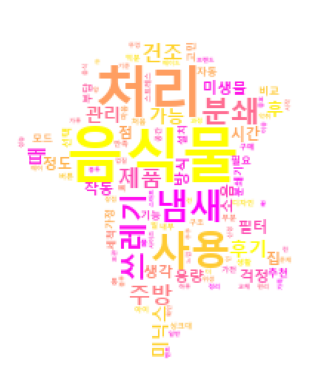

In [15]:
# 이미지 열어서 마스크이미지로 변환
# 이미지의 흰색 부분은 단어를 채우지 않고, 그 이외에 색이 있는 부분에 단어를 채우는 원리
img = Image.open('./data/jg.jpg')
mask_img = np.array(img)

wc = WordCloud(
    font_path='C:/Windows/Fonts/malgunbd.ttf',
    background_color='white', mask=mask_img, colormap='spring'
).generate_from_frequencies(dict(top_100))
plt.imshow(wc)
plt.axis('off')
plt.show()